# Система Росса: резерв и один ремонтник
Базовые параметры §7.3.3: N=10, S=3, пять запусков, средние времена 100 и 1 час.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("RossRepair.jl"))
using .RossRepair
using StableRNGs
include(srcdir("experiment_support.jl"))

mean_interval (generic function with 1 method)

## Пять последовательных прогонов исходного опыта
В исходном коде фактически используется StableRNG(42), хотя SEED=150 объявлен
отдельно и не применяется. Сохраняется действительная последовательность rng=42.

In [2]:
rng = StableRNG(42)
runs, trajectories = NamedTuple[], DataFrame[]
for run_id in 1:5
    result = simulate_repair(N=10,S=3,repairers=1,failure_mean=100.0,repair_mean=1.0;
        rng, verbose=true)
    push!(runs, merge((run=run_id, seed=42), result.summary))
    push!(trajectories, insertcols!(result.events, 1, :run=>run_id))
end
results, events = DataFrame(runs), vcat(trajectories...)
save_table("ross_runs.csv", results)
save_table("ross_events.csv", events)
println("Average crash time: ", mean(results.crash_time))
results

At time 12715.718224958666: No more spares!


At time 37335.53567595007: No more spares!


At time 30844.62667837361: No more spares!


At time 1601.2524911974856: No more spares!
At time 824.1048708405848: No more spares!
Average crash time: 16664.247588264083

Row,run,seed,N,S,repairers,failure_mean,repair_mean,crash_time,mean_queue,utilization,area_queue,area_busy,final_healthy,final_broken
,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64
1,1,42,10,3,1,100.0,1.0,12715.7,0.0127316,0.10182,161.891,1294.71,9,4
2,2,42,10,3,1,100.0,1.0,37335.5,0.0112276,0.0996571,419.189,3720.75,9,4
3,3,42,10,3,1,100.0,1.0,30844.6,0.0102358,0.100806,315.72,3109.33,9,4
4,4,42,10,3,1,100.0,1.0,1601.25,0.0145887,0.106319,23.3603,170.244,9,4
5,5,42,10,3,1,100.0,1.0,824.105,0.0176963,0.110306,14.5836,90.9035,9,4


## Аналитическое среднее время и мониторинг
Поглощение — первое достижение S+1 неисправных машин, а не просто нулевой резерв.
Загрузка и очередь усредняются по времени, не по числу записей событий.

In [3]:
theory = analytic_repair()
estimate = mean_interval(results.crash_time)
comparison = DataFrame([(runs=5, mean_time=estimate.mean, se=estimate.se,
    ci_low=estimate.ci_low, ci_high=estimate.ci_high, theory_time=theory.mean_time,
    utilization=sum(results.area_busy)/sum(results.crash_time), theory_utilization=theory.utilization,
    mean_queue=sum(results.area_queue)/sum(results.crash_time), theory_queue=theory.mean_queue)])
save_table("ross_comparison.csv", comparison)
save_table("ross_occupation_theory.csv", theory.occupation)
comparison

Row,runs,mean_time,se,ci_low,ci_high,theory_time,utilization,theory_utilization,mean_queue,theory_queue
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,5,16664.2,7489.26,0.0,37457.8,12340.0,0.100646,0.0996759,0.0112186,0.0105348


## Полная траектория первого запуска

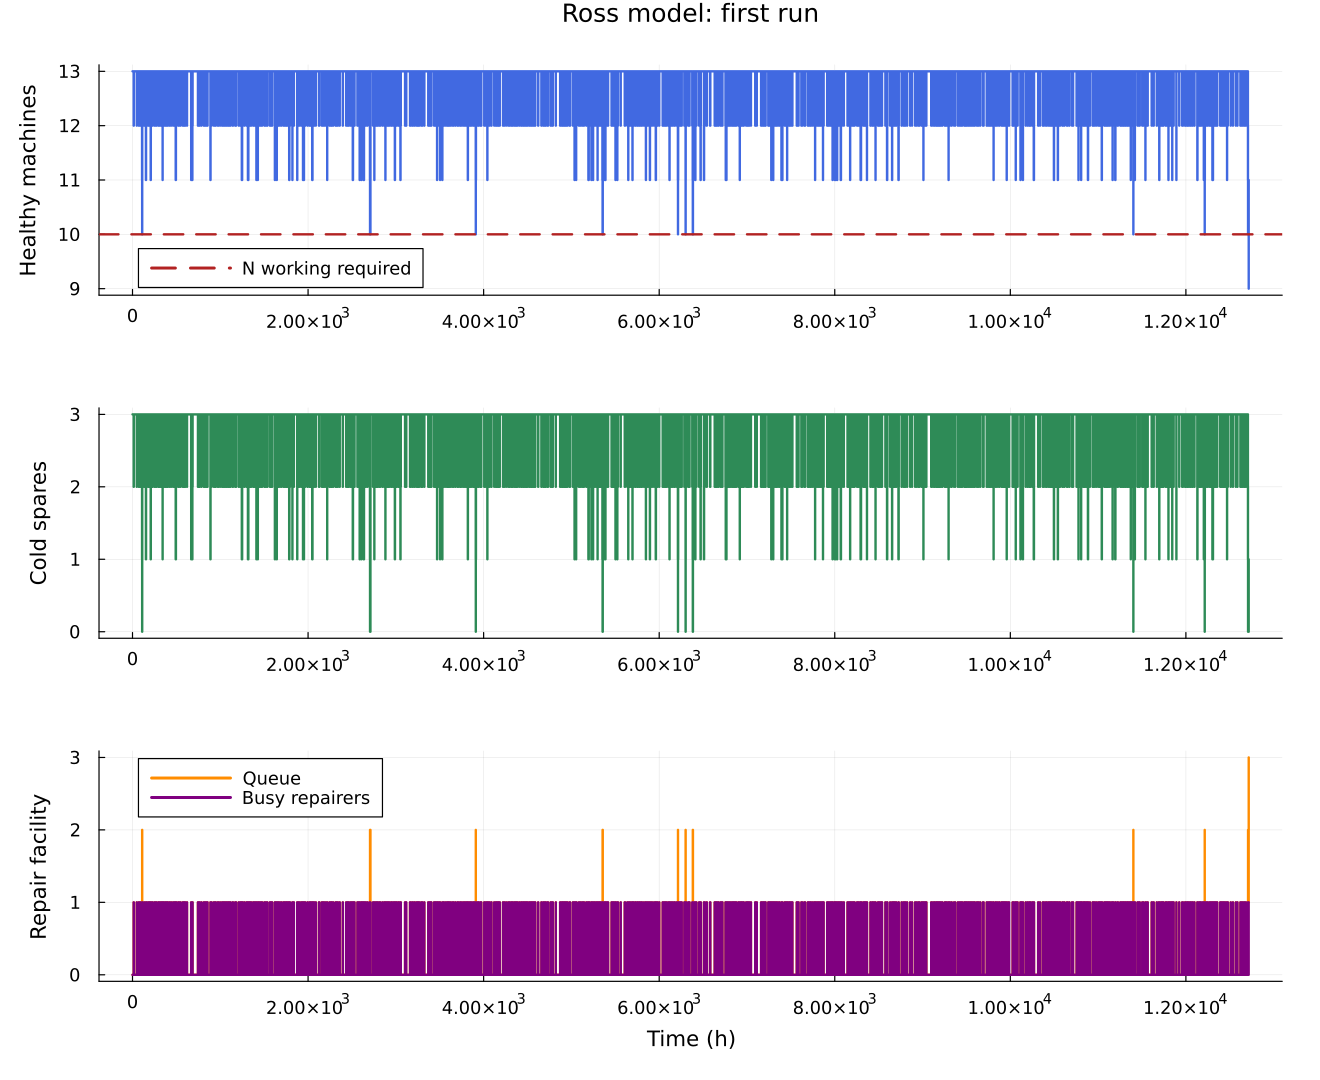

In [4]:
first_run = filter(:run=>==(1), events)
p_full = repair_plot(first_run,10)
savefig(p_full,imagepath("06-plot.png"))
display(p_full)

## Исчерпание резерва перед аварией

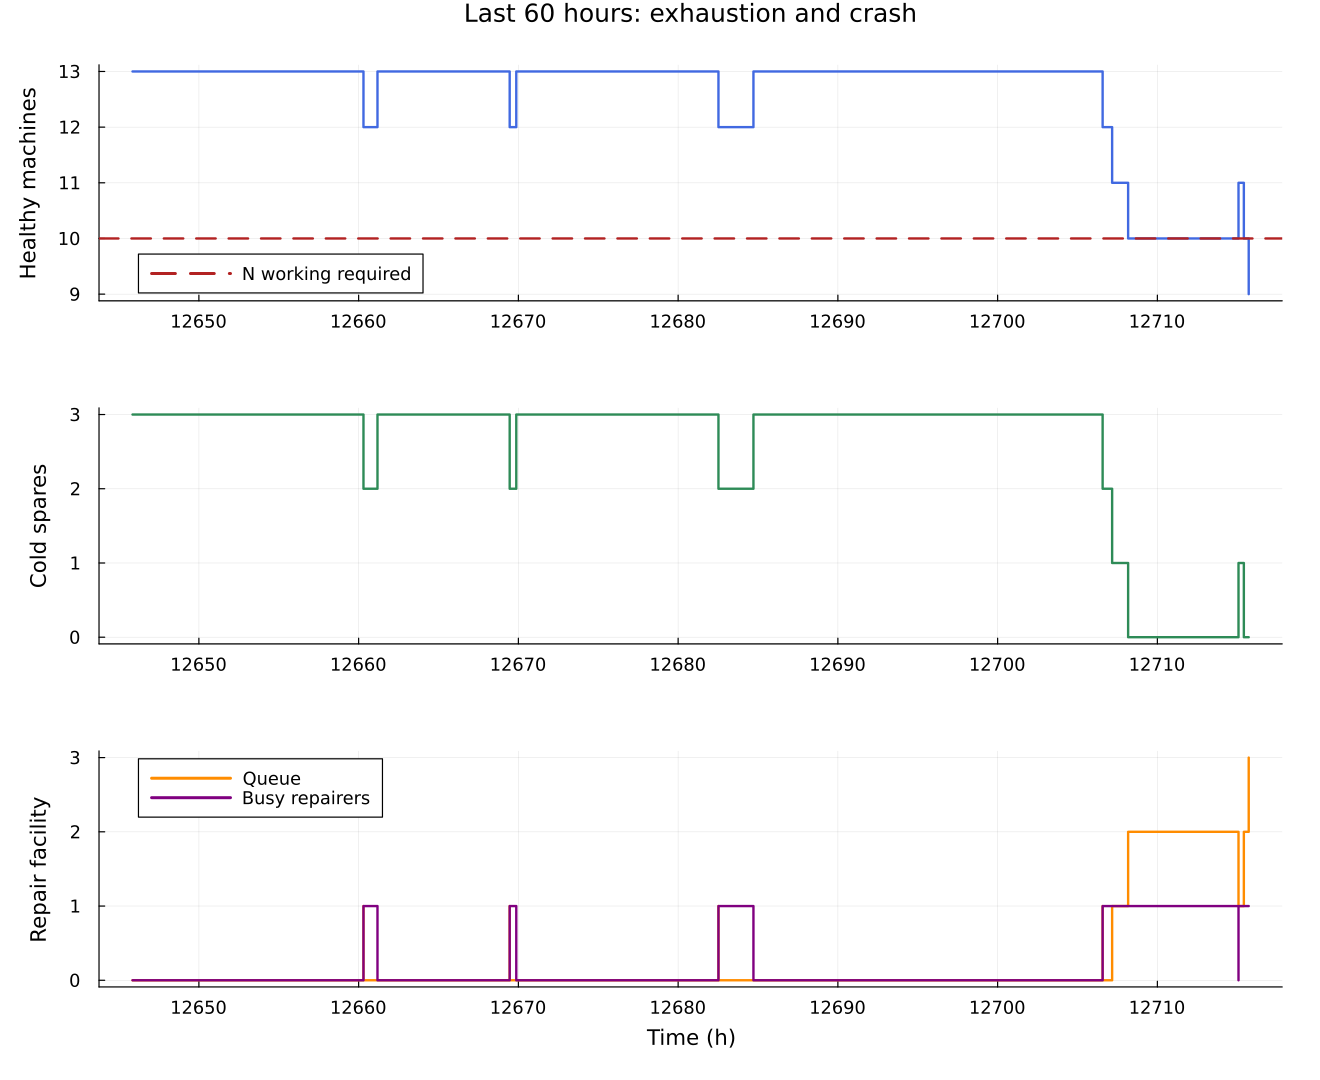

In [5]:
t_crash = last(first_run.time)
tail_start = max(0.0,t_crash-60)
prior = max(1,searchsortedlast(first_run.time,tail_start))
p_tail = repair_plot(first_run[prior:end,:],10; title="Last 60 hours: exhaustion and crash")
savefig(p_tail,imagepath("07-plot.png"))
display(p_tail)

## Разброс времени до падения

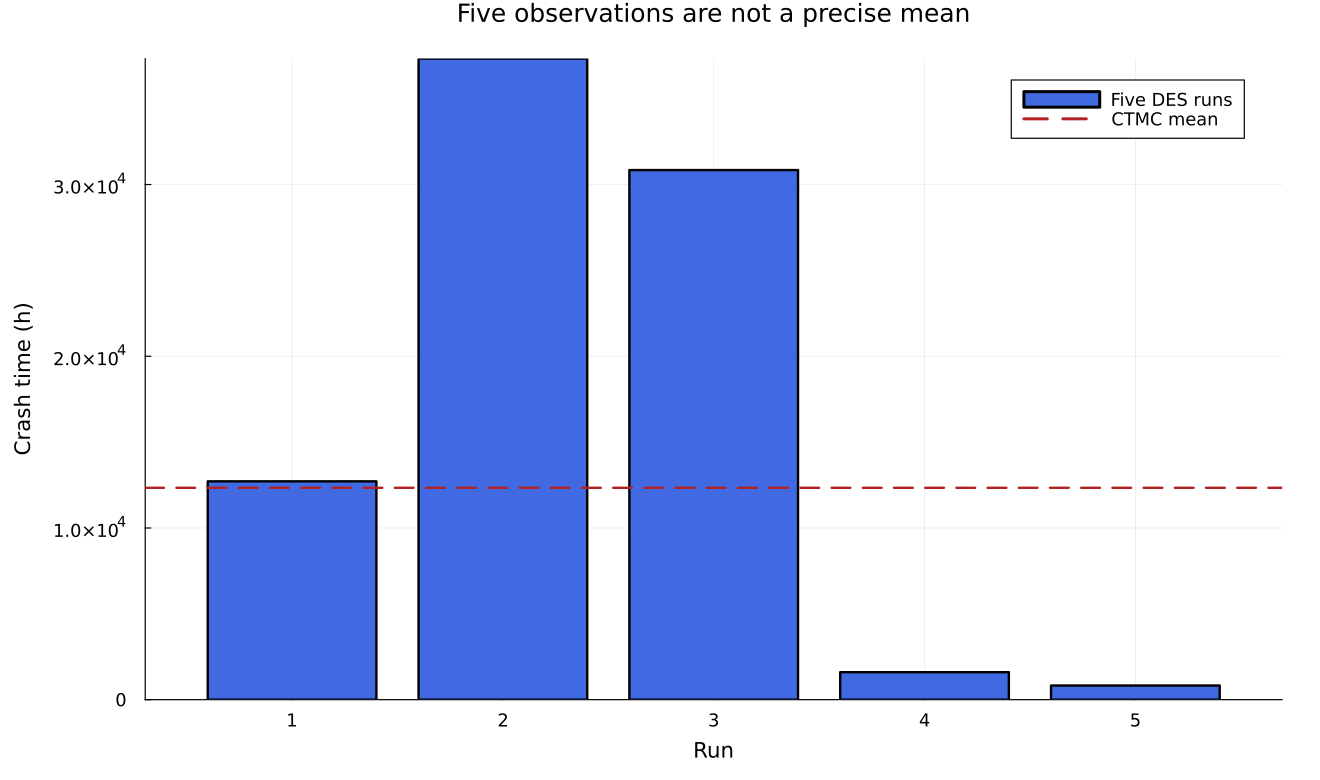

Row,broken,expected_time,fraction,busy,queue
,Int64,Float64,Float64,Int64,Int64
1,0,11110.0,0.900324,0,0
2,1,1110.0,0.0899514,1,0
3,2,110.0,0.0089141,1,1
4,3,10.0,0.000810373,1,2


In [6]:
p_runs = bar(results.run,results.crash_time; color=:royalblue, label="Five DES runs",
    xlabel="Run", ylabel="Crash time (h)", title="Five observations are not a precise mean")
hline!(p_runs,[theory.mean_time]; color=:firebrick, linestyle=:dash, label="CTMC mean")
savefig(p_runs,imagepath("08-plot.png"))
display(p_runs)
theory.occupation